# Arabic Handwritten Characters Classifier

## Data Loading

In [1]:
import pandas as pd

train_labels = pd.read_csv('data/labels/train.csv', header=None) - 1
test_labels = pd.read_csv('data/labels/test.csv', header=None) - 1

In [2]:
train_labels.head().values

array([[0],
       [0],
       [0],
       [0],
       [0]])

In [3]:
train_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 13440 entries, 0 to 13439
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       13440 non-null  int64
dtypes: int64(1)
memory usage: 105.1 KB


In [4]:
import tensorflow as tf

tf.random.set_seed(42)

train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/train',
    labels=train_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 13440 files belonging to 28 classes.
Using 10752 files for training.


In [5]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/train',
    labels=train_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 13440 files belonging to 28 classes.
Using 2688 files for validation.


In [6]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/test',
    labels=test_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 3360 files belonging to 28 classes.


## Visualization

In [7]:
class_names = ['أ', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ي']

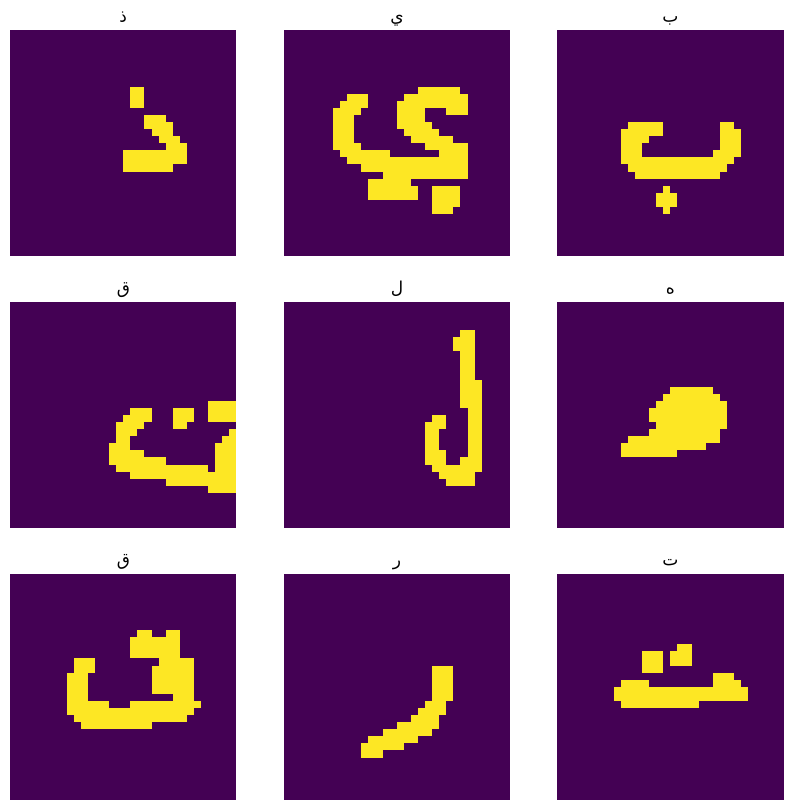

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## Modelling

### Training

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=64, kernel_size=5, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.GlobalMaxPooling2D(),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(28, activation='softmax')
])

In [10]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

In [11]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

Epoch 1/10


c:\Users\Seif Adin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


336/336 ━━━━━━━━━━━━━━━━━━━━ 88s 232ms/step - accuracy: 0.2101 - loss: 2.7917 - val_accuracy: 0.4721 - val_loss: 1.7699
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 65s 194ms/step - accuracy: 0.4543 - loss: 1.7618 - val_accuracy: 0.7853 - val_loss: 0.9003
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 69s 204ms/step - accuracy: 0.5745 - loss: 1.3238 - val_accuracy: 0.8322 - val_loss: 0.7250
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 69s 207ms/step - accuracy: 0.6565 - loss: 1.0747 - val_accuracy: 0.8735 - val_loss: 0.5151
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 66s 197ms/step - accuracy: 0.7050 - loss: 0.9295 - val_accuracy: 0.8925 - val_loss: 0.4276
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 65s 193ms/step - accuracy: 0.7474 - loss: 0.7979 - val_accuracy: 0.8914 - val_loss: 0.4052
Epoch 7/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 65s 194ms/step - accuracy: 0.7640 - loss: 0.7475 - val_accuracy: 0.9085 - val_loss: 0.3289
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 65s 192ms/step - accuracy: 0.7848 - loss: 0.6933 - val

The Model takes around 11 minutes to train getting an accuracy of around 92% on the validation set.

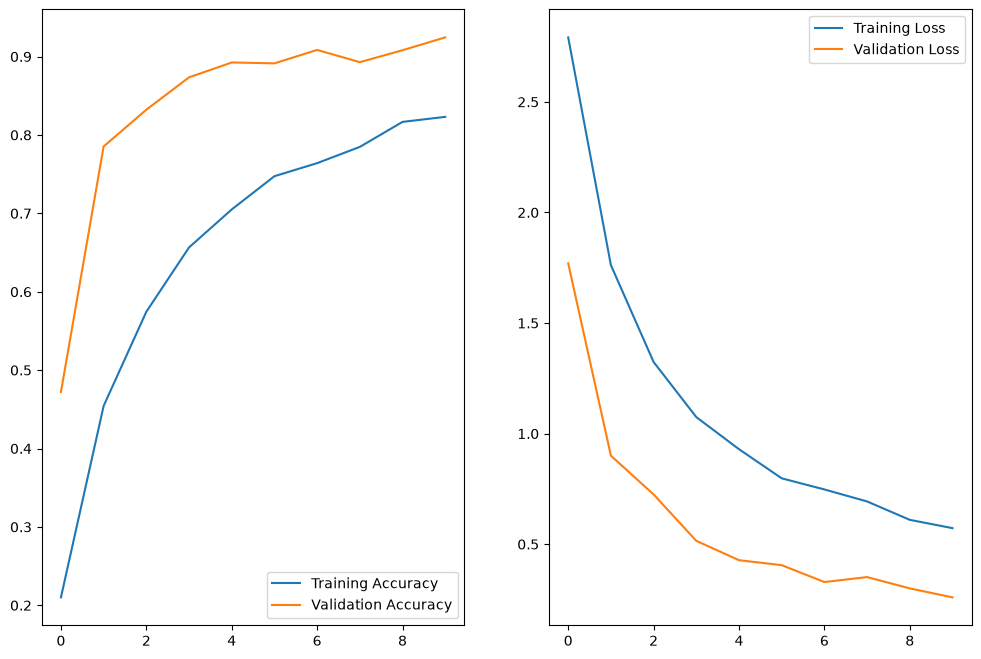

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].legend()

plt.show()

### Evaluating

In [13]:
images, labels = next(iter(test_ds))
new_images = images[:9]
new_labels = labels[:9]

new_labels

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([25, 15,  1, 11, 12,  8, 22, 24, 19], dtype=int32)>

In [14]:
import numpy as np

predictions = np.argmax(model.predict(new_images), axis=1)

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step


array([25, 15,  1, 11, 12,  8, 22, 24, 19])

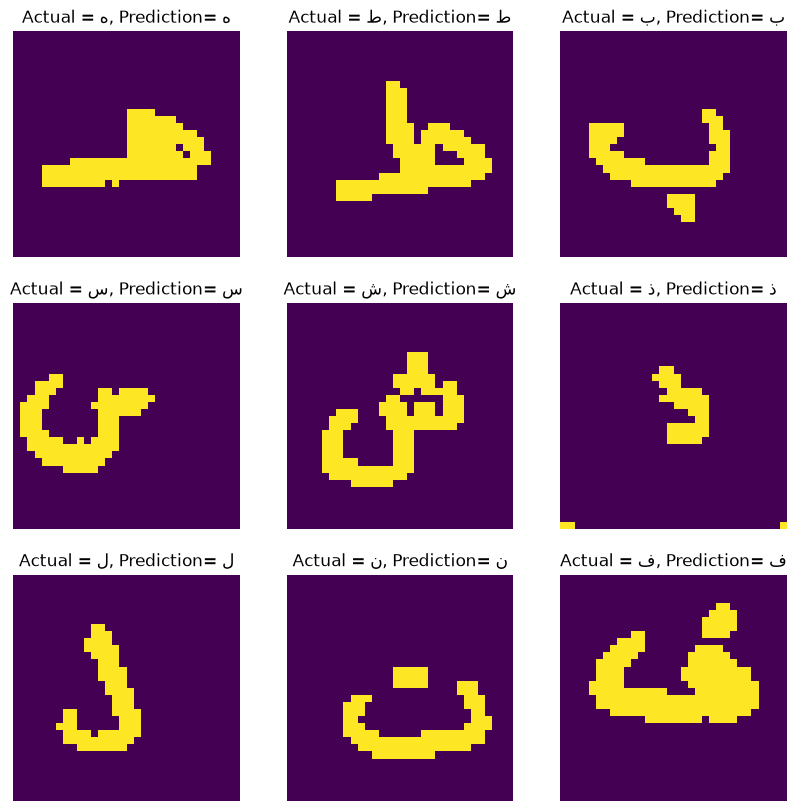

In [15]:
plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(new_images[i].numpy().astype("uint8"))
    plt.title(f'Actual = {class_names[new_labels[i]]}, Prediction= {class_names[predictions[i]]}')
    plt.axis("off")

In [16]:
train_full_ds = train_ds.concatenate(val_ds)

In [17]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

model.fit(train_full_ds, epochs=10)

Epoch 1/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 86s 188ms/step - accuracy: 0.8268 - loss: 0.5718
Epoch 2/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 79s 187ms/step - accuracy: 0.8409 - loss: 0.5232
Epoch 3/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 77s 184ms/step - accuracy: 0.8519 - loss: 0.4787
Epoch 4/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 78s 185ms/step - accuracy: 0.8551 - loss: 0.4738
Epoch 5/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 77s 184ms/step - accuracy: 0.8679 - loss: 0.4408
Epoch 6/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 78s 184ms/step - accuracy: 0.8743 - loss: 0.4225
Epoch 7/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 77s 184ms/step - accuracy: 0.8758 - loss: 0.4160
Epoch 8/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 79s 188ms/step - accuracy: 0.8905 - loss: 0.3711
Epoch 9/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 64s 153ms/step - accuracy: 0.8901 - loss: 0.3738
Epoch 10/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 71s 169ms/step - accuracy: 0.8933 - loss: 0.3586


### Saving

In [18]:
model.save('model_from_scratch.keras')

## Data Augmentation

In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.15)
])

In [20]:
base_model = tf.keras.models.load_model('model_from_scratch.keras')

In [21]:
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 32, 32, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 752,158 (2.87 MB)

 Trainable params: 250,462 (978.37 KB)

 Non-trainable params: 770 (3.01 KB)

 Optimizer params: 500,926 (1.91 MB)

In [22]:
for layer in base_model.layers[:8]:
    layer.trainable = False

In [23]:
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 32, 32, 1)      │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 752,158 (2.87 MB)

 Trainable params: 27,228 (106.36 KB)

 Non-trainable params: 224,004 (875.02 KB)

 Optimizer params: 500,926 (1.91 MB)

In [24]:
new_model = tf.keras.Sequential([
    data_augmentation,
    base_model,
])

In [25]:
new_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

In [26]:
history = new_model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 29s 80ms/step - accuracy: 0.8220 - loss: 0.6033 - val_accuracy: 0.9602 - val_loss: 0.1218
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 25s 75ms/step - accuracy: 0.8331 - loss: 0.5572 - val_accuracy: 0.9654 - val_loss: 0.1048
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 25s 74ms/step - accuracy: 0.8340 - loss: 0.5532 - val_accuracy: 0.9743 - val_loss: 0.0861
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 25s 75ms/step - accuracy: 0.8390 - loss: 0.5378 - val_accuracy: 0.9784 - val_loss: 0.0844
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 25s 74ms/step - accuracy: 0.8419 - loss: 0.5207 - val_accuracy: 0.9736 - val_loss: 0.0883
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 25s 74ms/step - accuracy: 0.8457 - loss: 0.5029 - val_accuracy: 0.9754 - val_loss: 0.0856
Epoch 7/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 25s 74ms/step - accuracy: 0.8455 - loss: 0.5201 - val_accuracy: 0.9747 - val_loss: 0.0833
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 25s 75ms/step - accuracy: 0.8493 - loss: 0.4928 - 

The Model takes around 4 minutes to train getting an accuracy of around 97% on the validation set.

In [27]:
new_predictions = np.argmax(model.predict(new_images), axis=1)

new_predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


array([25, 15,  1, 11, 12,  8, 22, 24, 19])

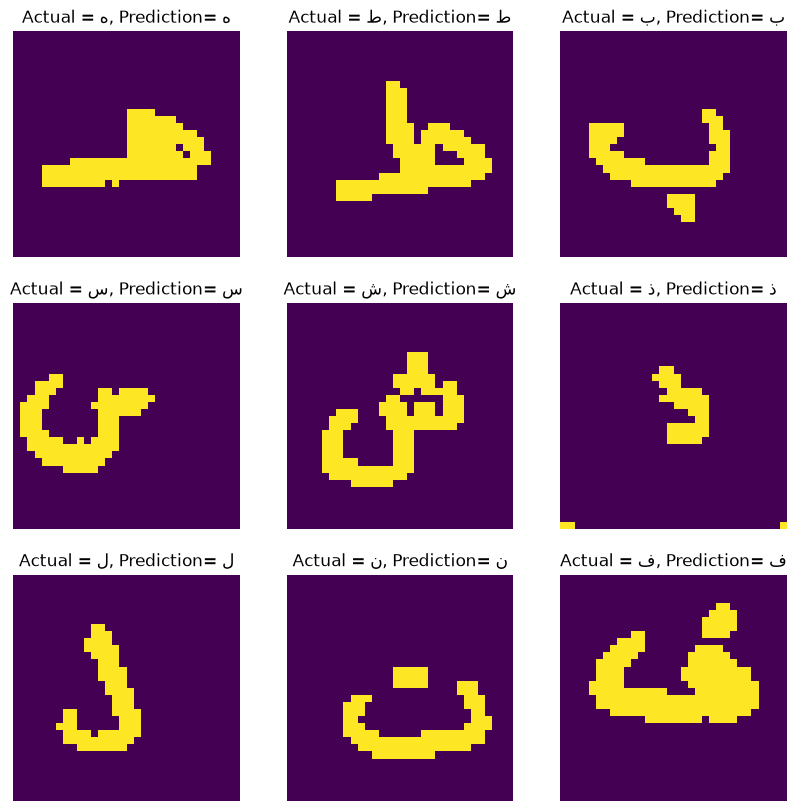

In [28]:
plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(new_images[i].numpy().astype("uint8"))
    plt.title(f'Actual = {class_names[new_labels[i]]}, Prediction= {class_names[new_predictions[i]]}')
    plt.axis("off")

In [29]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

new_model.fit(train_full_ds, epochs=10)

Epoch 1/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.8597 - loss: 0.4775
Epoch 2/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.8523 - loss: 0.4922
Epoch 3/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.8502 - loss: 0.5012
Epoch 4/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.8548 - loss: 0.4813
Epoch 5/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.8568 - loss: 0.4758
Epoch 6/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.8589 - loss: 0.4677
Epoch 7/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.8576 - loss: 0.4773
Epoch 8/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.8542 - loss: 0.4880
Epoch 9/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.8611 - loss: 0.4531
Epoch 10/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.8584 - loss: 0.4624


In [30]:
new_model.save('model_data_aug.keras')